# FIFA 23 EDA — Summary Dashboard

Comprehensive 4-panel dashboard combining insights from all previous analyses

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../data/FIFA23/FIFA23_official_data.csv')
print(f"Data loaded: {df.shape[0]} players")

Data loaded: 17660 players


In [2]:
# Parse currency values
def parse_currency(val):
    """Convert currency strings like '€115K' to numeric values"""
    if pd.isna(val) or val == '':
        return np.nan
    val = str(val).replace('€', '').strip()
    if 'M' in val:
        return float(val.replace('M', '')) * 1_000_000
    elif 'K' in val:
        return float(val.replace('K', '')) * 1_000
    else:
        return float(val) if val else np.nan

df['wage_numeric'] = df['Wage'].apply(parse_currency)
df['value_numeric'] = df['Value'].apply(parse_currency)
print("Currency columns parsed successfully")

Currency columns parsed successfully


✅ Summary dashboard saved to data/eda_summary.png


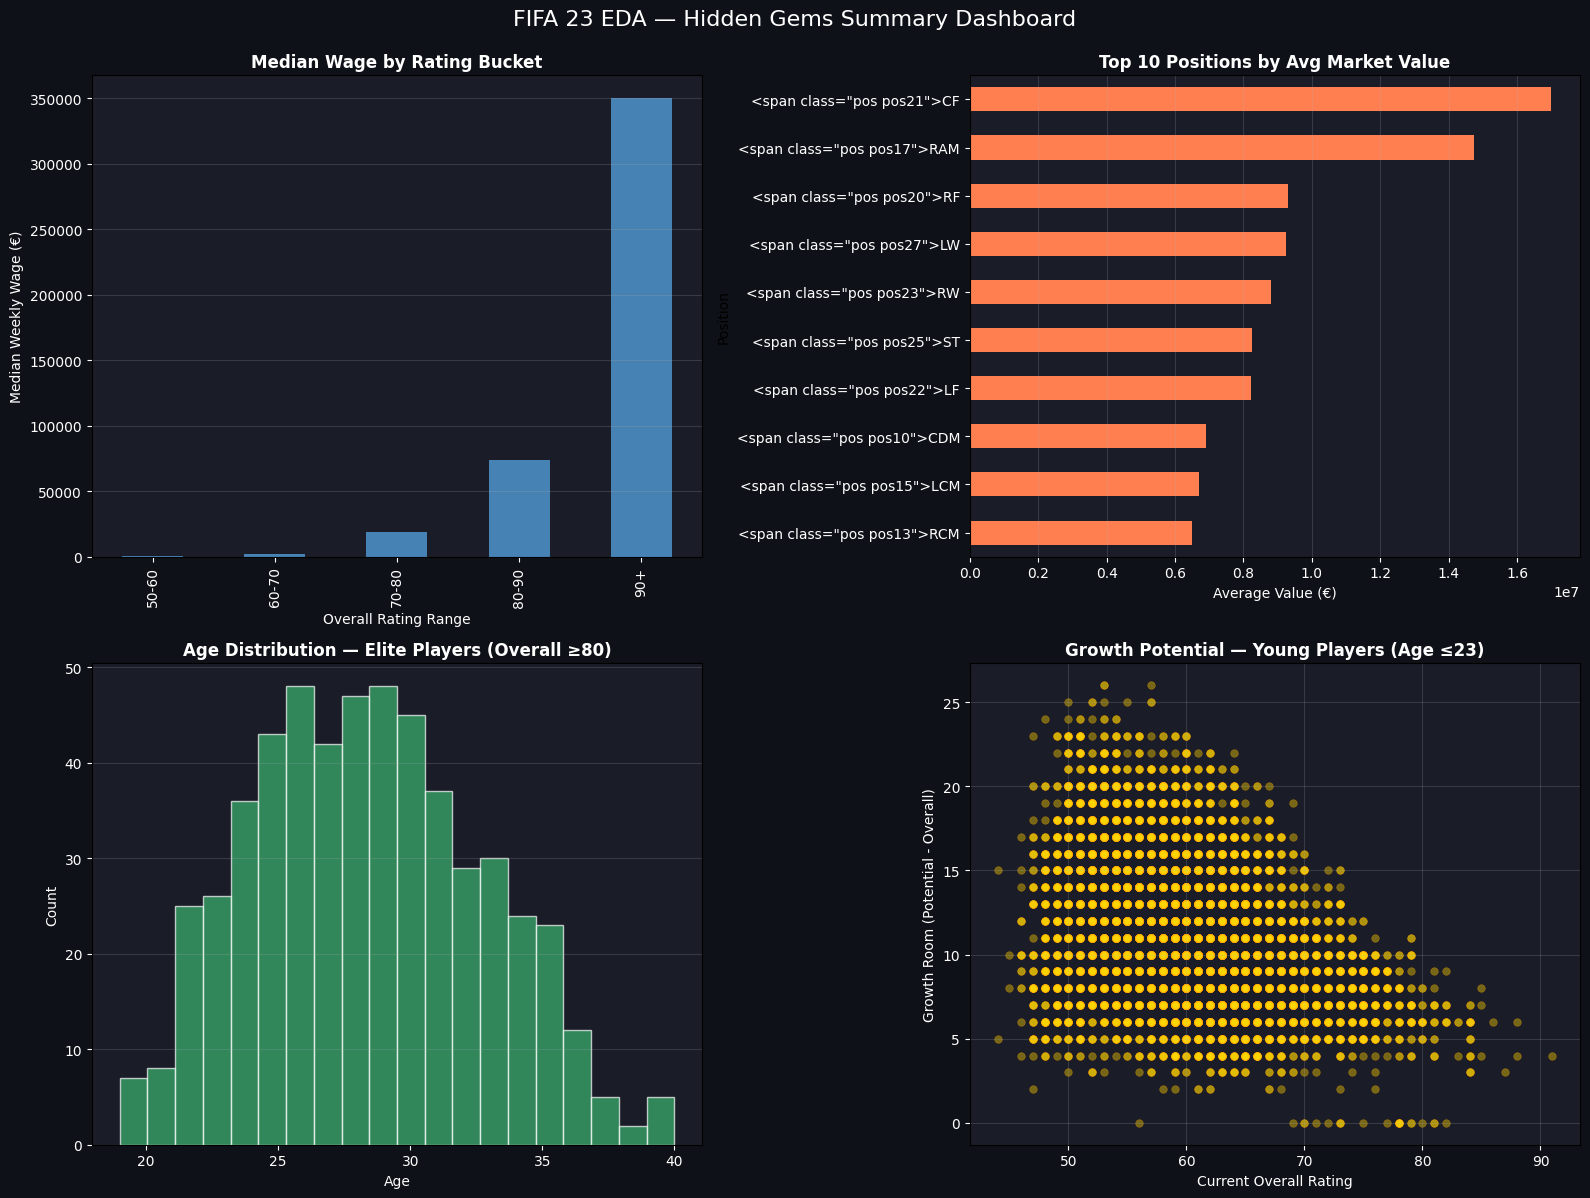

In [3]:
# Prepare data for dashboard
df['rating_bucket'] = pd.cut(df['Overall'], bins=[50, 60, 70, 80, 90, 100],
                              labels=['50-60', '60-70', '70-80', '80-90', '90+'])
df['growth_room'] = df['Potential'] - df['Overall']

# Create 2x2 summary dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('FIFA 23 EDA — Hidden Gems Summary Dashboard', fontsize=16, color='white', y=0.995)
fig.patch.set_facecolor('#0e1117')
for ax in axes.flat:
    ax.set_facecolor('#1a1d27')

# 1. Wage distribution by overall bucket
df.groupby('rating_bucket')['wage_numeric'].median().plot(
    kind='bar', ax=axes[0, 0], color='steelblue', edgecolor='none')
axes[0, 0].set_title('Median Wage by Rating Bucket', color='white', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Overall Rating Range', color='white')
axes[0, 0].set_ylabel('Median Weekly Wage (€)', color='white')
axes[0, 0].tick_params(colors='white')
axes[0, 0].grid(axis='y', alpha=0.2)

# 2. Position group avg value
grp = df.groupby('Position')['value_numeric'].mean().dropna().sort_values().tail(10)
grp.plot(kind='barh', ax=axes[0, 1], color='coral', edgecolor='none')
axes[0, 1].set_title('Top 10 Positions by Avg Market Value', color='white', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Average Value (€)', color='white')
axes[0, 1].tick_params(colors='white')
axes[0, 1].grid(axis='x', alpha=0.2)

# 3. Age distribution of elite players
df[df['Overall'] >= 80]['Age'].plot(kind='hist', bins=20,
    ax=axes[1, 0], color='mediumseagreen', edgecolor='white', alpha=0.7)
axes[1, 0].set_title('Age Distribution — Elite Players (Overall ≥80)', color='white', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Age', color='white')
axes[1, 0].set_ylabel('Count', color='white')
axes[1, 0].tick_params(colors='white')
axes[1, 0].grid(axis='y', alpha=0.2)

# 4. Growth room for young players (Potential - Overall gap)
young_players = df[df['Age'] <= 23].dropna(subset=['growth_room'])
axes[1, 1].scatter(young_players['Overall'], young_players['growth_room'], 
                   alpha=0.4, color='gold', s=30, edgecolors='orange', linewidth=0.5)
axes[1, 1].set_title('Growth Potential — Young Players (Age ≤23)', color='white', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Current Overall Rating', color='white')
axes[1, 1].set_ylabel('Growth Room (Potential - Overall)', color='white')
axes[1, 1].tick_params(colors='white')
axes[1, 1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('../data/eda_summary.png', dpi=150, bbox_inches='tight', facecolor='#0e1117')
print("✅ Summary dashboard saved to data/eda_summary.png")
plt.show()